In [29]:
from pathlib import Path
import json
from typing import cast, Dict, List
import testing
from run_types import CompRes
import pandas as pd      # not imported previously, so do it here
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

In [30]:
exps_dict_path = Path('./results/S3D_32_SAICIST.json')
print(exps_dict_path.exists())

True


In [31]:
with open(exps_dict_path, 'r') as f:
    exps_dict = json.load(f)

In [32]:

print(len(exps_dict['asl100']))

1


In [33]:
exps_dict = cast(Dict[str, Dict[str, List[str]]], exps_dict)

In [34]:
from typing import Any
def sort_dict(dict: Dict[str, Any]) -> Dict[str, Any]:
    return {key : value for key, value in sorted(dict.items(), key=lambda x: x[0])}

In [35]:
for key, value in exps_dict.items():
    exps_dict[key] = sort_dict(value)

In [36]:
total_summarised = {}
for split, asl_exps in exps_dict.items():
    runs_dir = Path('./runs') / split
    
    summarised = {}
    for model_name, exps in asl_exps.items():
        expno = exps[0]
        print(f'{model_name} : {expno}')
        results_path = runs_dir / f'{model_name}_exp{expno}' / 'results' / 'best_val_loss.json'
        with open(results_path, 'r') as f:
            entry_res = cast(CompRes, json.load(f))
        

        res_key1 = "top_k_average_per_class_acc"
        res_key2 = "top_k_per_instance_acc"

        summarised[model_name] = {
            'exp': expno,
            res_key1 : entry_res['test'][res_key1],
            res_key2 : entry_res['test'][res_key2]
        }

    total_summarised[split] = summarised

exps_summarised_dict_path = exps_dict_path.parent / exps_dict_path.name.replace('.json', '_summarised.json')
with open(exps_summarised_dict_path, 'w') as f:
    json.dump(total_summarised, f, indent=4)

S3D : 023
S3D : 046
S3D : 047
S3D : 048


In [37]:
# acc_key = "top_k_average_per_class_acc"
acc_key = "top_k_per_instance_acc"
acc_titles = {
    "top_k_average_per_class_acc": "Average Per-Class Accuracy",
    "top_k_per_instance_acc": "Per instance Accuracy"
}

In [38]:
def get_data_frame(split_sum: Dict[str, Dict[str, Dict[str, float]]], acc_key: str) -> pd.DataFrame:
    rows = []
    top1, top5, top10 = 'top1', 'top5', 'top10'
    for model_name, res_d in split_sum.items():
        rows.append({
            'Model': model_name,
            top1: res_d[acc_key][top1],
            top5: res_d[acc_key][top5],
            top10: res_d[acc_key][top10],
        })
    return pd.DataFrame(rows)

In [39]:
print(acc_titles[acc_key])
for split, summarised in total_summarised.items():
    print(f'{split}')
    display(get_data_frame(summarised, acc_key))
    # print(get_data_frame(summarised))



Per instance Accuracy
asl100


,Model,top1,top5,top10
0,S3D,0.542636,0.844961,0.906977


asl300


,Model,top1,top5,top10
0,S3D,0.54491,0.806886,0.872754


asl1000


,Model,top1,top5,top10
0,S3D,0.377399,0.678571,0.777186


asl2000


,Model,top1,top5,top10
0,S3D,0.17124,0.410212,0.532824


Saved to: /home/luke/Code/SLR/code/results/bar_all_splits.pdf


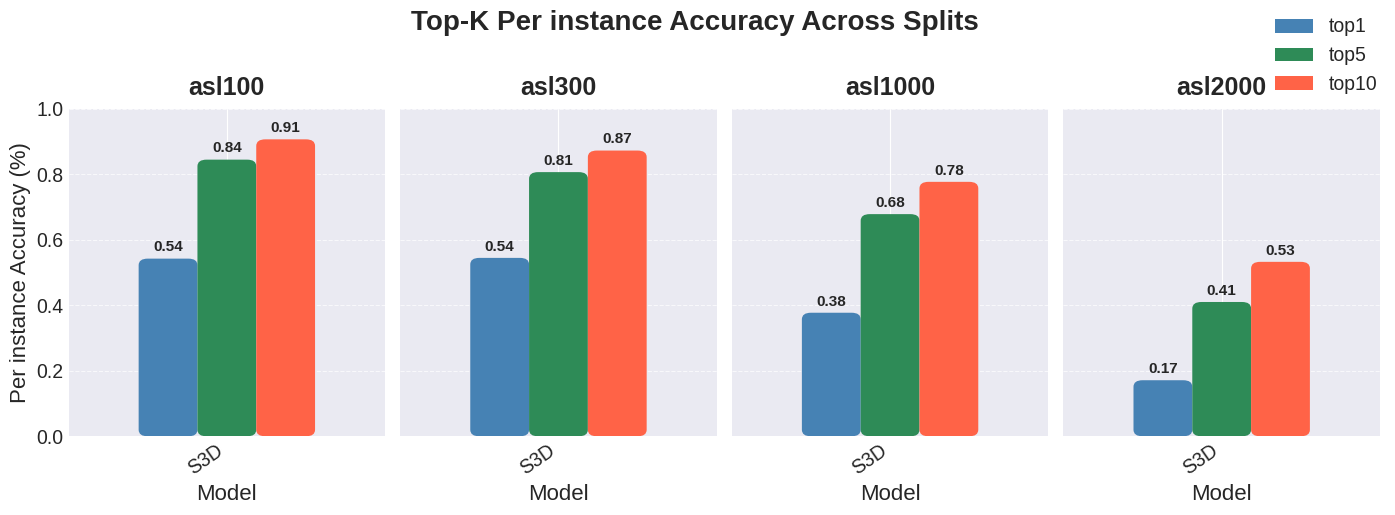

In [40]:
def plot_all_splits(total_summarised: Dict[str, Dict[str, Dict[str, float]]]):
    import os
    from matplotlib.patches import FancyBboxPatch
    os.makedirs('results', exist_ok=True)

    n_splits = len(total_summarised)
    fig, axes = plt.subplots(1, n_splits, figsize=(3.5 * n_splits, 5), sharey=True)

    if n_splits == 1:
        axes = [axes]

    width = 0.13  # thinner bars
    radius = 0.02  # rounding radius — increase for more pronounced rounding
    colors = {'top1': 'steelblue', 'top5': 'seagreen', 'top10': 'tomato'}

    def draw_rounded_bar(ax, x, y, width, color, radius):
        """Draw a single rounded bar using FancyBboxPatch."""
        box = FancyBboxPatch(
            (x - width / 2, 0), width, y,
            boxstyle=f"round,pad=0,rounding_size={radius}",
            linewidth=0, color=color
        )
        ax.add_patch(box)

    for ax, (split_name, split_sum) in zip(axes, total_summarised.items()):
        df = get_data_frame(split_sum, acc_key)
        models = df['Model']
        x = np.arange(len(models)) * 0.55  # very tight group spacing

        for i, (metric, color) in enumerate(colors.items()):
            offset = (i - 1) * width
            for j, val in enumerate(df[metric]):
                draw_rounded_bar(ax, x[j] + offset, val, width, color, radius)
                ax.annotate(f'{val:.2f}',
                            xy=(x[j] + offset, val),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=11, fontweight='bold')

        # Dummy bars for the legend
        for metric, color in colors.items():
            ax.bar(0, 0, color=color, label=metric)

        ax.set_title(split_name, fontsize=18, fontweight='bold', pad=10)
        ax.set_xlabel('Model', fontsize=16)
        ax.set_xticks(x)
        ax.set_xticklabels(models, rotation=35, ha='right', fontsize=14)
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax.tick_params(axis='y', labelsize=14)
        ax.set_axisbelow(True)
        ax.set_xlim(x[0] - 0.35, x[-1] + 0.35)
        ax.set_ylim(0, 1.0)

    axes[0].set_ylabel(f'{acc_titles[acc_key]} (%)', fontsize=16)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper right', fontsize=14)
    fig.suptitle(f'Top-K {acc_titles[acc_key]} Across Splits', fontsize=20, fontweight='bold', y=1.02)

    plt.tight_layout()

    output_path = 'results/bar_all_splits.pdf'
    plt.savefig(output_path, bbox_inches='tight')
    print(f"Saved to: {os.path.abspath(output_path)}")
    plt.show()

plot_all_splits(total_summarised)

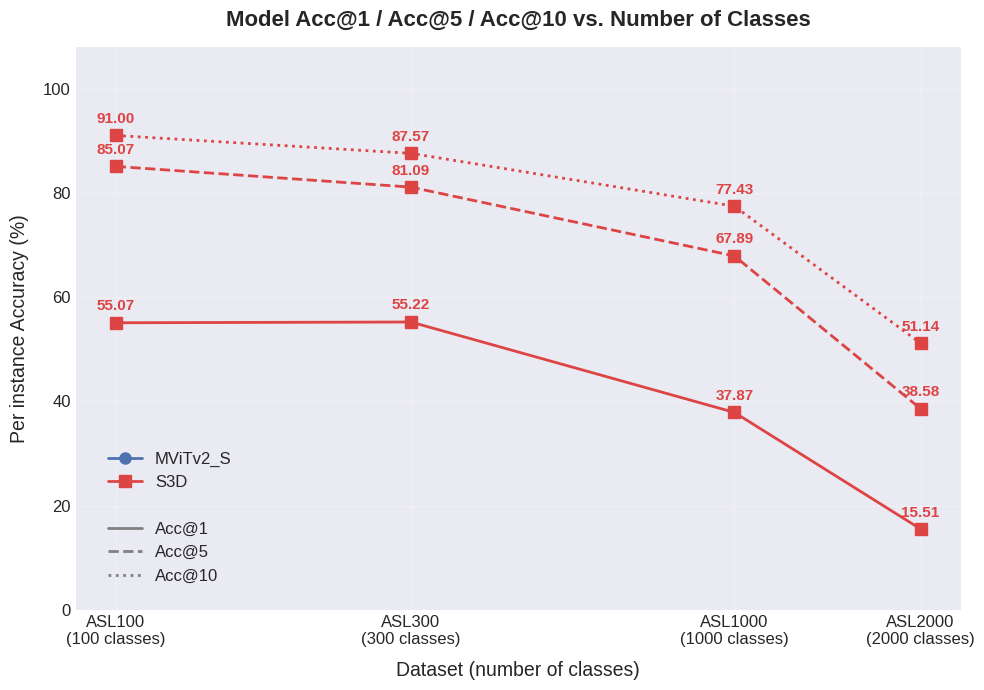

In [41]:


n_classes = [100, 300, 1000, 2000]
splits = [f"asl{n}" for n in n_classes]

# 1. Initialize the data dictionary dynamically based on the models
models = list(total_summarised[splits[0]].keys())
data = {model: {"top1": [], "top5": [], "top10": []} for model in models}

# 2. Populate the dictionary with actual results, converted to percentages
for split in splits:
    for model in models:
        metrics = total_summarised[split][model]["top_k_average_per_class_acc"]
        data[model]["top1"].append(metrics["top1"] * 100)
        data[model]["top5"].append(metrics["top5"] * 100)
        data[model]["top10"].append(metrics["top10"] * 100)

model_styles = {
    "MViTv2_S": {"color": "#4C72B0", "marker": "o"},
    "S3D":      {"color": "#DD4444", "marker": "s"},
}

topk_styles = {
    "top1":  {"linestyle": "-",  "label": "Acc@1"},
    "top5":  {"linestyle": "--", "label": "Acc@5"},
    "top10": {"linestyle": ":",  "label": "Acc@10"},
}

fig, ax = plt.subplots(figsize=(10, 7)) # Slightly increased figure size to accommodate larger text

for model_name, metrics in data.items():
    style = model_styles[model_name]
    for k, tk_style in topk_styles.items():
        ax.plot(
            n_classes, metrics[k],
            marker=style["marker"],
            color=style["color"],
            linestyle=tk_style["linestyle"],
            linewidth=2.0,
            markersize=8,
            label=f"{model_name} {tk_style['label']}",
        )
        for x, y in zip(n_classes, metrics[k]):
            ax.annotate(
                f"{y:.2f}",
                xy=(x, y),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                fontsize=11,          # INCREASED: Data point labels
                fontweight="bold",    # ADDED: Bold text for better visibility
                color=style["color"],
            )

ax.set_xscale("log")
ax.set_xticks(n_classes)

# INCREASED: X and Y tick labels
ax.set_xticklabels([f"ASL{n}\n({n} classes)" for n in n_classes], fontsize=12)
ax.tick_params(axis='y', labelsize=12) 




# INCREASED: Axis labels
ax.set_xlabel("Dataset (number of classes)", fontsize=14, labelpad=10)
ax.set_ylabel(f"{acc_titles[acc_key]} (%)", fontsize=14, labelpad=10)

# INCREASED: Title size
ax.set_title("Model Acc@1 / Acc@5 / Acc@10 vs. Number of Classes", fontsize=16, fontweight='bold', pad=15)

ax.set_ylim(0, 108) # Slightly expanded y-limit so the top annotations don't get cut off
ax.grid(True, linestyle="--", alpha=0.4)

# Two-level legend: group by model (color) and by metric (linestyle)

legend_elements = [
    # Models
    Line2D([0], [0], color="#4C72B0", marker="o", linewidth=2.0, markersize=8, label="MViTv2_S"),
    Line2D([0], [0], color="#DD4444", marker="s", linewidth=2.0, markersize=8, label="S3D"),
    # Spacer
    Line2D([0], [0], color="none", label=""),
    # Top-k
    Line2D([0], [0], color="grey", linestyle="-",  linewidth=2.0, label="Acc@1"),
    Line2D([0], [0], color="grey", linestyle="--", linewidth=2.0, label="Acc@5"),
    Line2D([0], [0], color="grey", linestyle=":",  linewidth=2.0, label="Acc@10"),
]

# INCREASED: Legend font size
ax.legend(handles=legend_elements, fontsize=12, loc="lower left", bbox_to_anchor=(0.02, 0.02)) 
# Note: Moved legend to lower left to prevent overlapping with the data points in the top right

plt.tight_layout()
plt.savefig("topk_vs_classes.pdf", dpi=150)
plt.show()

In [42]:
latex_titles = {
    "top_k_average_per_class_acc": "Mean Per-Class",
    "top_k_per_instance_acc": "Per Instance"
}

def print_latex_table(total_summarised):
    # LaTeX boilerplate header
    latex_str = f"""\\begin{{table}}[htbp]
\\centering
\\caption{{{latex_titles[acc_key]} top-$k$ accuracy (\\%) across all WLASL splits under the tuned hyperparameter configuration.}}
\\label{{tab:main_res}}
\\begin{{tabular}}{{|l|l|ccc|}}
\\hline
\\textbf{{Split}} & \\textbf{{Model}} & \\textbf{{Acc@1}} & \\textbf{{Acc@5}} & \\textbf{{Acc@10}} \\\\
\\hline"""

    # Iterate over each split in the data
    for split, split_data in total_summarised.items():
        # Format "asl100" -> "WLASL100"
        split_name = split.replace('asl', 'WLASL')
        models = list(split_data.keys())

        # Identify maximum values in the current split for bolding
        max_top1 = max(split_data[m][acc_key]["top1"] for m in models)
        max_top5 = max(split_data[m][acc_key]["top5"] for m in models)
        max_top10 = max(split_data[m][acc_key]["top10"] for m in models)

        for i, model in enumerate(models):
            # Escape underscore for LaTeX
            model_name = model.replace('_', '\\_')
            metrics = split_data[model][acc_key]

            # Convert to percentages and format to 2 decimal places
            top1_str = f"{metrics['top1'] * 100:.2f}"
            top5_str = f"{metrics['top5'] * 100:.2f}"
            top10_str = f"{metrics['top10'] * 100:.2f}"

            # Apply bold formatting to the best values
            if metrics['top1'] == max_top1:
                top1_str = f"\\textbf{{{top1_str}}}"
            if metrics['top5'] == max_top5:
                top5_str = f"\\textbf{{{top5_str}}}"
            if metrics['top10'] == max_top10:
                top10_str = f"\\textbf{{{top10_str}}}"

            # Only print the split name on the first row of the group
            col1_text = split_name if i == 0 else ""
            
            # Format row with consistent spacing for clean raw LaTeX code
            row = f"{col1_text:<9} & {model_name:<10} & {top1_str:<14} & {top5_str:<14} & {top10_str} \\\\"
            latex_str += "\n" + row

        latex_str += "\n\\hline"

    # LaTeX boilerplate footer
    latex_str += """
\\end{tabular}
\\end{table}"""

    print(latex_str)

# Call the function
print_latex_table(total_summarised)

\begin{table}[htbp]
\centering
\caption{Per Instance top-$k$ accuracy (\%) across all WLASL splits under the tuned hyperparameter configuration.}
\label{tab:main_res}
\begin{tabular}{|l|l|ccc|}
\hline
\textbf{Split} & \textbf{Model} & \textbf{Acc@1} & \textbf{Acc@5} & \textbf{Acc@10} \\
\hline
WLASL100  & S3D        & \textbf{54.26} & \textbf{84.50} & \textbf{90.70} \\
\hline
WLASL300  & S3D        & \textbf{54.49} & \textbf{80.69} & \textbf{87.28} \\
\hline
WLASL1000 & S3D        & \textbf{37.74} & \textbf{67.86} & \textbf{77.72} \\
\hline
WLASL2000 & S3D        & \textbf{17.12} & \textbf{41.02} & \textbf{53.28} \\
\hline
\end{tabular}
\end{table}
